# 02 Exploratory Data Analysis

This notebook analyzes the processed Amazon Reviews 2023 data produced by the preprocessing step. The preprocessing result justified this focus: the dataset has 25,023 interactions, 3,744 users, 3,700 items, density of 0.0018063496188496187, and 0.0% missing images. That means the most important questions are sparsity, long-tail concentration, category balance, and temporal behavior.

## Why this analysis comes next

The preprocessing output used the 3-core fallback, not 5-core, because the real dataset in this workspace is small after filtering. That means the EDA notebook should validate whether the retained sample is still large enough for baseline recommendation training and whether one category dominates the interaction history.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from recsys.config import get_settings

settings = get_settings()
interactions_path = settings.processed_data_dir / 'interactions.parquet'
items_path = settings.processed_data_dir / 'items.parquet'

interactions = pd.read_parquet(interactions_path)
items = pd.read_parquet(items_path)

print('interactions shape:', interactions.shape)
print('items shape:', items.shape)
print('users:', interactions['user_id'].nunique())
print('items:', interactions['item_id'].nunique())
print('density:', len(interactions) / (interactions['user_id'].nunique() * interactions['item_id'].nunique()))

interactions shape: (25023, 5)
items shape: (3700, 9)
users: 3744
items: 3700
density: 0.0018063496188496187


## Sparsity and long-tail checks

Because the density is far below 1%, the first diagnostic is the user/item interaction distribution. This tells us whether the candidate generators need a popularity fallback and whether a few items dominate the training signal.

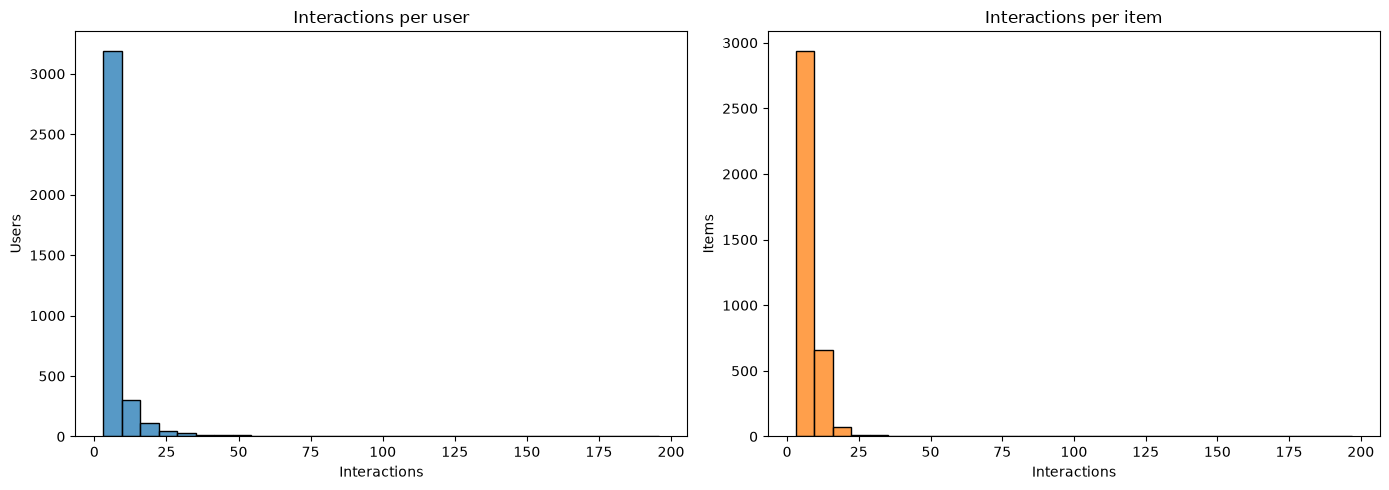

Top 10 items by interactions:
item_id
B07XVVVB8W    197
B0B4328BFW    116
B0BHRWHHJV     74
B0B5XFVSXY     66
B0B93L6V3C     39
B0BQ36KZH2     34
B0BQ47DNW2     33
B0BR4GL7Q6     31
B0CB33QW6H     31
B0BBSFXYP5     31
dtype: int64


In [2]:
user_counts = interactions.groupby('user_id').size().sort_values(ascending=False)
item_counts = interactions.groupby('item_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(user_counts, bins=30, ax=axes[0], color='#1f77b4')
axes[0].set_title('Interactions per user')
axes[0].set_xlabel('Interactions')
axes[0].set_ylabel('Users')

sns.histplot(item_counts, bins=30, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Interactions per item')
axes[1].set_xlabel('Interactions')
axes[1].set_ylabel('Items')

plt.tight_layout()
plt.show()

print('Top 10 items by interactions:')
print(item_counts.head(10))

## Category balance

The preprocessing notebook kept all three target categories, so this notebook checks whether one category is overly dominant. That matters because the serving logic needs category-aware fallbacks for cold start and for the 'Popular in <top category>' rail.

,item_count
category,
All Beauty,1694
Health & Personal Care,1262
Handmade,708
Premium Beauty,32
AMAZON FASHION,2
Amazon Home,2


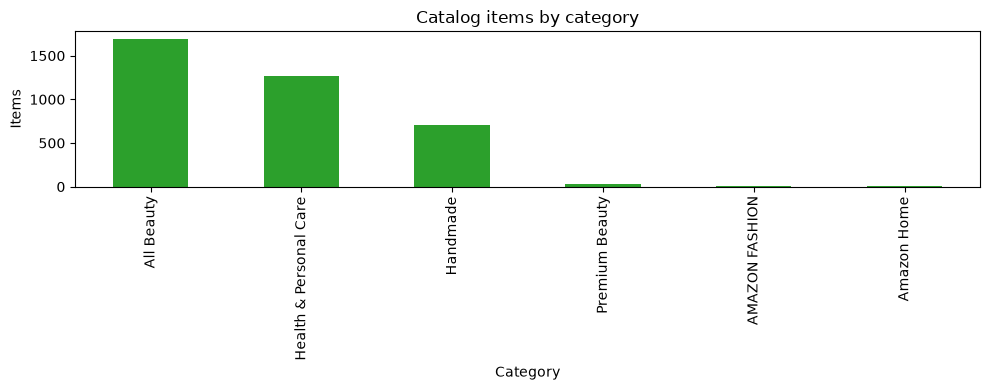

In [3]:
category_counts = items['category'].fillna('Unknown').value_counts()
display(category_counts.to_frame('item_count'))

plt.figure(figsize=(10, 4))
category_counts.plot(kind='bar', color='#2ca02c')
plt.title('Catalog items by category')
plt.xlabel('Category')
plt.ylabel('Items')
plt.tight_layout()
plt.show()

## Temporal coverage

The interaction timestamps determine whether leave-last-out evaluation is meaningful. If the timeline is short or uneven, the holdout split still works, but the notebook should document the limitation instead of pretending the sample is dense enough for stronger assumptions.

earliest: 2007-02-21 01:30:06
latest: 2023-08-08 23:11:14.122000
days covered: 6012


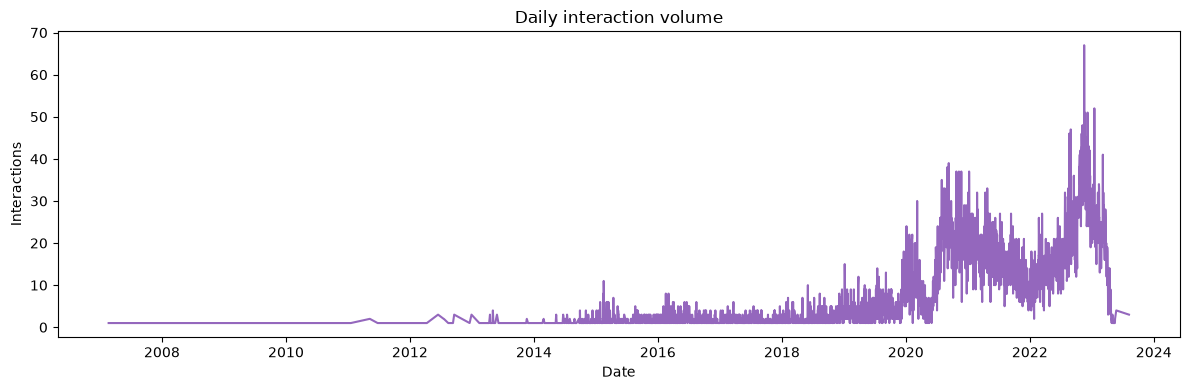

In [4]:
ts = pd.to_datetime(interactions['timestamp'], unit='ms')
print('earliest:', ts.min())
print('latest:', ts.max())
print('days covered:', (ts.max() - ts.min()).days)

daily_counts = ts.dt.date.value_counts().sort_index()
plt.figure(figsize=(12, 4))
daily_counts.plot(color='#9467bd')
plt.title('Daily interaction volume')
plt.xlabel('Date')
plt.ylabel('Interactions')
plt.tight_layout()
plt.show()

## Exported artifacts

This notebook is analysis-only. It does not write new model artifacts. Its role is to justify the next baseline and evaluation notebooks from the actual processed dataset, which is sparse but usable.